# Sea Surface Salinity Satellites and Data



## Imports

We will use `numpy` for calculations, `pandas` for tabular summaries, and `matplotlib` for simple plots.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (8, 4),
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.5,
})

# Part 2: SSS Satellites and Higher-Level Data Products

Satellite SSS observations became possible once L-band radiometers with sufficiently large antennas could be flown in space. The main satellite missions are **SMOS**, **Aquarius**, and **SMAP**.

In [7]:
missions = pd.DataFrame({
    'Mission': ['SMOS', 'Aquarius/SAC-D', 'SMAP', 'CIMR'],
    'Agency': ['ESA', 'NASA / CONAE', 'NASA', 'ESA / Copernicus'],
    'Launch / Operation': ['Launched 2009; ongoing', '2011-2015', 'Launched 2015; ongoing', 'Scheduled for launch in 2026'],
    'Instrument': ['MIRAS L-band interferometric radiometer', 'Aquarius L-band radiometer', 'L-band passive radiometer', 'Multi-frequency microwave radiometer'],
    'Approximate SSS Resolution': ['~50 km', '~76 km along track', '~70 km', '~5 km monthly product expected'],
    'Notes': [
        'First dedicated satellite for soil moisture and ocean salinity',
        'Ended after a power supply failure',
        'Radar failed early, but passive radiometer continued',
        'Future higher-resolution microwave mission'
    ]
})
missions

,Mission,Agency,Launch / Operation,Instrument,Approximate SSS Resolution,Notes
0,SMOS,ESA,Launched 2009; ongoing,MIRAS L-band interferometric radiometer,~50 km,First dedicated satellite for soil moisture an...
1,Aquarius/SAC-D,NASA / CONAE,2011-2015,Aquarius L-band radiometer,~76 km along track,Ended after a power supply failure
2,SMAP,NASA,Launched 2015; ongoing,L-band passive radiometer,~70 km,"Radar failed early, but passive radiometer con..."
3,CIMR,ESA / Copernicus,Scheduled for launch in 2026,Multi-frequency microwave radiometer,~5 km monthly product expected,Future higher-resolution microwave mission


## Timeline of satellite SSS observations

Compared with SST, ocean color, and sea ice, the satellite SSS record is relatively short. L-band instruments for global SSS retrievals began in 2009 with SMOS.

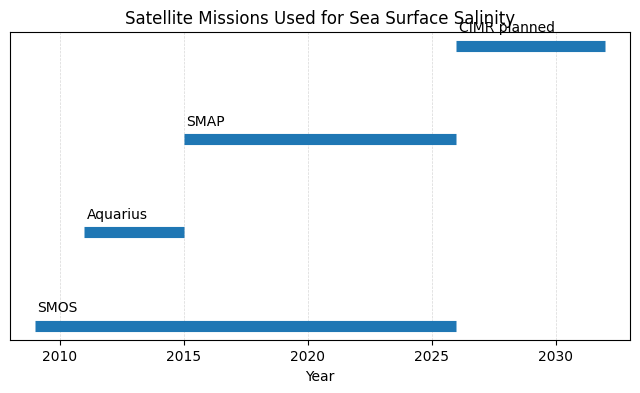

In [8]:
# Simple mission timeline plot
mission_intervals = [
    ('SMOS', 2009, 2026),
    ('Aquarius', 2011, 2015),
    ('SMAP', 2015, 2026),
    ('CIMR planned', 2026, 2032),
]

y = np.arange(len(mission_intervals))
for i, (name, start, end) in enumerate(mission_intervals):
    plt.hlines(i, start, end, linewidth=8)
    plt.text(start + 0.1, i + 0.15, name)

plt.yticks([])
plt.xlabel('Year')
plt.title('Satellite Missions Used for Sea Surface Salinity')
plt.xlim(2008, 2033)
plt.show()

## Higher-level SSS products

As with SST, SSS data are available at multiple processing levels. Higher-level products are usually easier to use because data have been mapped to common grids and may include gap filling through interpolation.

Level 4 SSS products combine multiple satellite observations and fill gaps in space and time, often using optimal interpolation. These products are useful for broad-scale analysis, but interpolated values should be interpreted cautiously, especially near land, sea ice, or strong gradients.

In [9]:
levels = pd.DataFrame({
    'Level': ['Level 0', 'Level 1', 'Level 2', 'Level 3', 'Level 4'],
    'Description': [
        'Raw instrument or engineering data',
        'Calibrated/geolocated radiances or brightness temperatures',
        'Retrieved geophysical variables such as SSS in swath format',
        'Mapped gridded products',
        'Merged and gap-filled products, often using interpolation and/or models'
    ],
    'Typical Use': [
        'Instrument processing',
        'Algorithm development',
        'Detailed retrieval studies',
        'Regional or global mapping',
        'Time-series analysis and broad-scale science applications'
    ]
})
levels

,Level,Description,Typical Use
0,Level 0,Raw instrument or engineering data,Instrument processing
1,Level 1,Calibrated/geolocated radiances or brightness ...,Algorithm development
2,Level 2,Retrieved geophysical variables such as SSS in...,Detailed retrieval studies
3,Level 3,Mapped gridded products,Regional or global mapping
4,Level 4,"Merged and gap-filled products, often using in...",Time-series analysis and broad-scale science a...


### Check your understanding

Why were global satellite SSS observations not available until 2009, even though satellite observations of SST, ocean color, and sea ice began much earlier?

Think about the role of:

- L-band frequency,
- antenna size,
- required measurement precision,
- contamination from other microwave sources.